In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root)not in sys.path:
    sys.path.append(str(project_root))
from src.modeling import load_feature_data, compare_models


In [2]:
DATA_DIR = project_root / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
DB_PATH = project_root / "db" / "energy_load.db"

df = load_feature_data(DB_PATH)
df.head()

,source_file,interval_start,interval_end,week_label,week_number,area_name,area_code,forecast_min_mw,actual_min_mw,actual_max_mw,...,actual_max_mw_diff_1,actual_max_mw_pct_change_1,forecast_min_mw_diff_1,forecast_min_mw_pct_change_1,forecast_max_mw_diff_1,forecast_max_mw_pct_change_1,range_actual_mw,range_forecast_mw,range_actual_diff_1,range_forecast_diff_1
0,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30,Week 1,1,Poland,PL,12898.5,12992.96,24945.56,...,NaN,NaN,NaN,NaN,NaN,NaN,11952.60,14801.5,NaN,NaN
1,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30,Week 2,2,Poland,PL,14170.9,15513.79,25954.28,...,1008.72,0.040437,1272.4,0.098647,0.0,0.0,10440.49,13529.1,-1512.11,-1272.4
2,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30,Week 3,3,Poland,PL,15434.4,15798.93,25264.46,...,-689.82,-0.026578,1263.5,0.089162,0.0,0.0,9465.53,12265.6,-974.96,-1263.5
3,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30,Week 4,4,Poland,PL,15483.2,16055.43,26135.58,...,871.12,0.034480,48.8,0.003162,0.0,0.0,10080.15,12216.8,614.62,-48.8
4,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30,Week 5,5,Poland,PL,15090.6,14985.68,25339.89,...,-795.69,-0.030445,-392.6,-0.025357,0.0,0.0,10354.21,12609.4,274.06,392.6


In [3]:
df.shape


(418, 80)

In [4]:
df.columns.tolist()

['source_file',
 'interval_start',
 'interval_end',
 'week_label',
 'week_number',
 'area_name',
 'area_code',
 'forecast_min_mw',
 'actual_min_mw',
 'actual_max_mw',
 'forecast_max_mw',
 'data_year',
 'created_at',
 'year',
 'month',
 'quarter',
 'week_of_year',
 'season',
 'is_winter',
 'is_spring',
 'is_summer',
 'is_autumn',
 'week_sin',
 'week_cos',
 'error_min_mw',
 'error_max_mw',
 'abs_error_min_mw',
 'abs_error_max_mw',
 'actual_min_mw_lag_1',
 'actual_min_mw_lag_2',
 'actual_min_mw_lag_3',
 'actual_min_mw_lag_4',
 'actual_max_mw_lag_1',
 'actual_max_mw_lag_2',
 'actual_max_mw_lag_3',
 'actual_max_mw_lag_4',
 'forecast_min_mw_lag_1',
 'forecast_min_mw_lag_2',
 'forecast_min_mw_lag_3',
 'forecast_min_mw_lag_4',
 'forecast_max_mw_lag_1',
 'forecast_max_mw_lag_2',
 'forecast_max_mw_lag_3',
 'forecast_max_mw_lag_4',
 'actual_min_mw_roll_mean_3',
 'actual_min_mw_roll_std_3',
 'actual_min_mw_roll_mean_4',
 'actual_min_mw_roll_std_4',
 'actual_min_mw_roll_mean_8',
 'actual_min_mw_rol

<div dir = "rtl">

### اجرای مقایسه مدل‌ها

In [5]:
results_df = compare_models(df, target_col="actual_max_mw", test_size=0.2)
results_df


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,MAE,RMSE,MAPE,R2
0,Baseline (Last Value),2010.319052,2280.377835,8.964617,-0.271235
1,Random Forest,302.038579,489.336995,1.319083,0.941463
2,XGBoost,247.463770,344.370929,1.086472,0.971009
3,"ARIMA(2,1,2)",1706.258899,2075.338287,7.445460,-0.052907


<div dir = "rtl">

### مرتب‌سازی نتایج

In [6]:
results_df = results_df.sort_values("RMSE")
results_df


,Model,MAE,RMSE,MAPE,R2
2,XGBoost,247.463770,344.370929,1.086472,0.971009
1,Random Forest,302.038579,489.336995,1.319083,0.941463
3,"ARIMA(2,1,2)",1706.258899,2075.338287,7.445460,-0.052907
0,Baseline (Last Value),2010.319052,2280.377835,8.964617,-0.271235


<div dir = "rtl">

### نمودار مقایسه MAE

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12448\640275858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", palette="viridis")


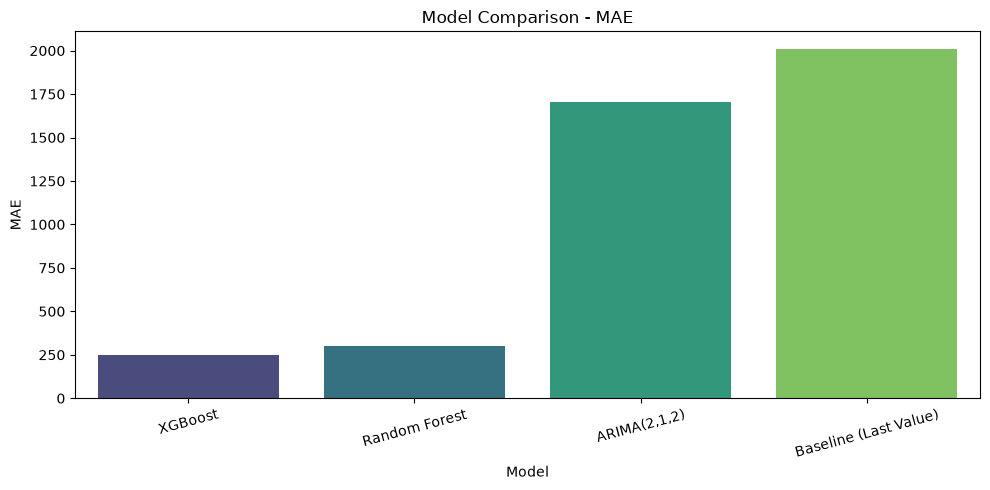

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="MAE", palette="viridis")
plt.title("Model Comparison - MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


<div dir = "rtl">

### نمودار مقایسه RMSE

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12448\2088491471.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="magma")


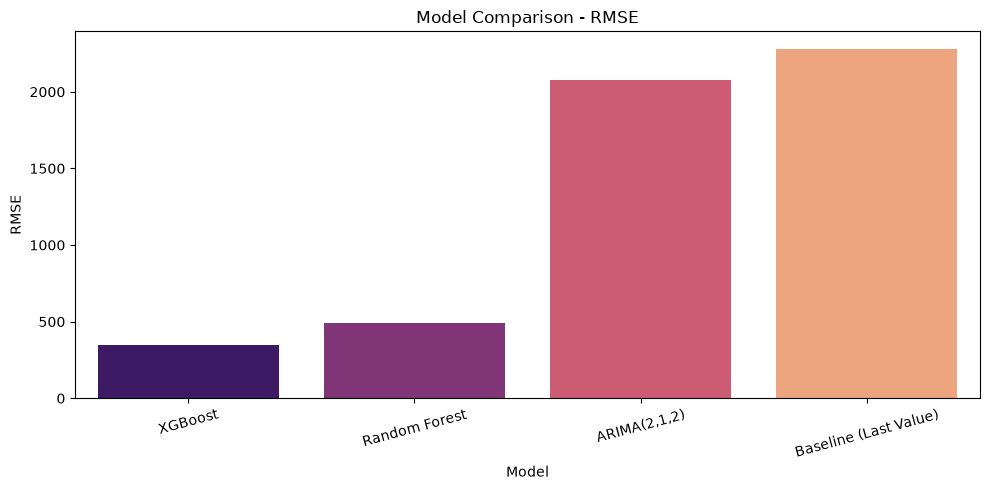

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="magma")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



<div dir = "rtl">

### نمودار مقایسه MAPE

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12448\3945374807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAPE", palette="coolwarm")


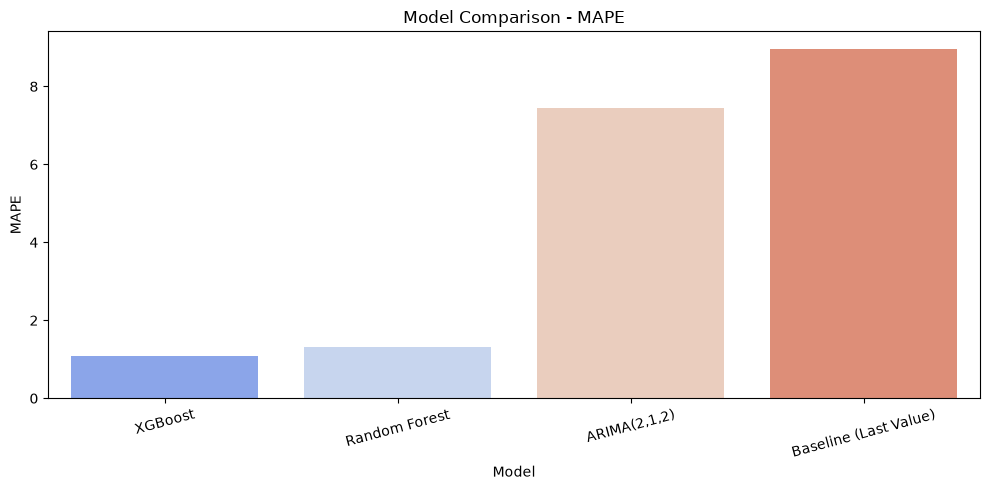

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="MAPE", palette="coolwarm")
plt.title("Model Comparison - MAPE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


<div dir = "rtl">

### ذخیره نتایج

In [10]:
results_df.to_csv("../data/processed/model_comparison_results.csv", index=False)
results_df


,Model,MAE,RMSE,MAPE,R2
2,XGBoost,247.463770,344.370929,1.086472,0.971009
1,Random Forest,302.038579,489.336995,1.319083,0.941463
3,"ARIMA(2,1,2)",1706.258899,2075.338287,7.445460,-0.052907
0,Baseline (Last Value),2010.319052,2280.377835,8.964617,-0.271235
